In [1]:
import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
path = '80long.bin'
num_cols = 6
data_type = np.int16
num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data = np.memmap(path, dtype = data_type, mode = 'r', shape = (num_rows, num_cols))

print(num_rows)
print(data[0:5])
print(data[-6:-1])

983140
[[ 2782    70  2871    33   471     0]
 [ 2195    60  1251    82  6165     0]
 [ 2864    65  1597    65    38     0]
 [ 1104    82  1466    87   630     0]
 [ 1667    18  1100     7 -4971     0]]
[[ 2057    10  2431   115 -1281  3599]
 [ 1980    99  2025    68   459  3599]
 [ 1691   111  1904   116  -339  3599]
 [ 2583   123  1634    10  6689  3599]
 [ 2518    10  2546    10  -245  3599]]


In [3]:
# Event counts per channel
eventcounts = np.zeros(6144, dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data[i:i+1000000]
    #ids = np.asarray(chunk[:, [0, 1]], dtype = np.int32)
    ids = np.asarray(chunk[:, [1, 3]], dtype = np.int32)
    ids[:, 0] = ids[:, 0] + 128
    np.add.at(eventcounts, ids, 1)
print(np.sum(eventcounts))

Event counts: 100%|██████████| 1/1 [00:00<00:00, 14.00it/s]

1966280


In [51]:
eventcounts = np.asarray(eventcounts, dtype = np.float32)
eventcounts = eventcounts / 300

with open('/home/kale-chen/Documents/PET/MDA_03162026/Data/hcentereventrates.txt', 'w') as f:
    for i in range(6144):
        f.write(f'{eventcounts[i]}\n')


In [64]:
# Event counts per time bin
binwidth = 10
heights, edges = np.histogram(data[:, 5], bins = np.arange(data[:, 5].min(), data[:, 5].max() + binwidth, binwidth))
with open('/home/kale-chen/Documents/PET/MDA_03162026/Data/mvert_timebinned.txt', 'w') as f:
    for i in range(len(heights)):
        f.write(f'{heights[i]}\n')


In [11]:
run_time = data[:, 5].max() - data[:, 5].min()
num_time_bins = int(np.ceil(run_time / 60))
eventcounts_timebinned = np.zeros((6144, num_time_bins), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc='Event counts'):
    chunk = data[i:i+1000000]
    idls = np.asarray(chunk[:, 1] + 3072, dtype = np.int32)
    idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    times = np.asarray(chunk[:, 5] // 60, dtype = np.int32)
    np.add.at(eventcounts_timebinned, (idls, times), 1)
    np.add.at(eventcounts_timebinned, (idrs, times), 1)
print(np.sum(eventcounts_timebinned))

Event counts: 100%|██████████| 106/106 [00:12<00:00,  8.81it/s]

211830914


In [20]:
# All LORs event counts
dir = '/home/kale-chen/Documents/PET/TimeCalibration/MiniPET/'
name = '80short'

path = f'{dir}/{name}.bin'
num_cols = 6
data_type = np.int16
num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data1 = np.memmap(path, dtype = data_type, mode = 'r', shape = (num_rows, num_cols))
event_counts1 = np.zeros((128, 128), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc=''):
    chunk = data1[i:i+1000000]
    idls = np.asarray(chunk[:, 1], dtype = np.int32)
    idrs = np.asarray(chunk[:, 3], dtype = np.int32)
    np.add.at(event_counts1, (idls, idrs), 1)
print(np.sum(event_counts1))

path = f'{dir}/{name}_pcut.bin'
num_cols = 3
data_type = np.int16
num_rows = os.path.getsize(path) // (num_cols * data_type().itemsize)
data2 = np.memmap(path, dtype = data_type, mode = 'r', shape = (num_rows, num_cols))
event_counts2 = np.zeros((128, 128), dtype = np.int32)
for i in tqdm(range(0, num_rows, 1000000), desc=''):
    chunk = data2[i:i+1000000]
    idls = np.asarray(chunk[:, 0], dtype = np.int32)
    idrs = np.asarray(chunk[:, 1], dtype = np.int32)
    np.add.at(event_counts2, (idls, idrs), 1)
print(np.sum(event_counts2))


100%|██████████| 1/1 [00:00<00:00, 19.36it/s]


984286


100%|██████████| 1/1 [00:00<00:00, 114.64it/s]

170833


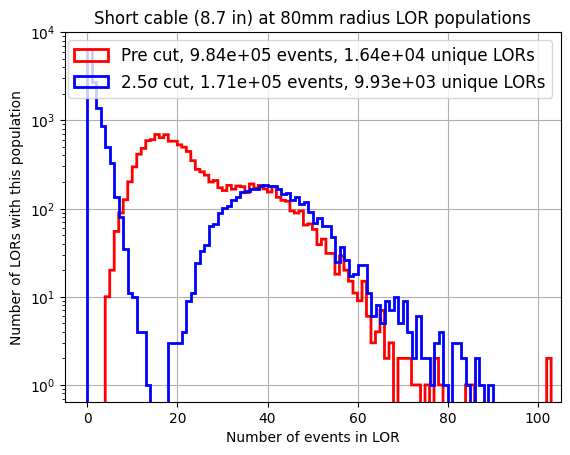

In [21]:
# LOR populations histogram
def format_number(number):
    return f"{number:.2e}"
plt.hist(event_counts1.flatten(), bins = np.max(event_counts1.flatten()), color = 'red', alpha = 1, label = f'Pre cut, {format_number(np.sum(event_counts1))} events, {format_number(len(np.where(event_counts1 > 0)[0]))} unique LORs', histtype = 'step', linewidth = 2)
plt.hist(event_counts2.flatten(), bins = np.max(event_counts2.flatten()), color = 'blue', alpha = 1, label = f'2.5σ cut, {format_number(np.sum(event_counts2))} events, {format_number(len(np.where(event_counts2 > 0)[0]))} unique LORs', histtype = 'step', linewidth = 2)
#plt.hist(event_counts3.flatten(), bins = np.max(event_counts3.flatten()), color = 'green', alpha = 1, label = f'HWHM cut, {format_number(np.sum(event_counts3))} events, {format_number(len(np.where(event_counts3 > 0)[0]))} unique LORs', histtype = 'step', linewidth = 2)
#plt.hist(event_counts4.flatten(), bins = np.max(event_counts4.flatten()), color = 'orange', alpha = 1, label = f'1σ cut, {format_number(np.sum(event_counts4))} events, {format_number(len(np.where(event_counts4 > 0)[0]))} unique LORs', histtype = 'step', linewidth = 2)
plt.xlim(-5, 105)
plt.yscale('log')
plt.xlabel('Number of events in LOR')
plt.ylabel('Number of LORs with this population')
plt.title('Short cable (8.7 in) at 80mm radius LOR populations')
plt.grid()
legend = plt.legend(fontsize = 12)
plt.show()


In [167]:
lor_list = []
for i in range(3072):
    for j in range(3072):
        if event_counts2[i, j] == 5:
            lor_list.append((i, j, 5))
lor_list = np.asarray(lor_list, dtype = np.int16)
sample_size = min(1000, len(lor_list))
sampled_lors = lor_list[np.random.choice(len(lor_list), sample_size, replace=False)]
print(sampled_lors.shape)
topl_filename = '/home/kale-chen/Documents/PET/MDA_03162026/Data/hcenter_5_toplors.bin'
with open(topl_filename, 'wb') as topl_fp:
    sampled_lors.tofile(topl_fp)


(1000, 3)


In [85]:
path = '/home/kale-chen/Documents/PET/MDA_03162026/Data/hcenter.dat'
length = 0
for chunk in tqdm(pd.read_csv(path, header = None, delimiter = '\t', chunksize = 1000000), desc=''):
    length += len(chunk)
timesL, timesR = np.zeros(length, dtype = np.int64), np.zeros(length, dtype = np.int64)
for i, chunk in tqdm(enumerate(pd.read_csv(path, header = None, delimiter = '\t', chunksize = 1000000, usecols = [2, 7])), desc=''):
    timesL[i * 1000000:(i + 1) * 1000000] = np.asarray(chunk.iloc[:, 0], dtype = np.int64)
    timesR[i * 1000000:(i + 1) * 1000000] = np.asarray(chunk.iloc[:, 1], dtype = np.int64)
time_diffsL = timesL[1:] - timesL[:-1]
time_diffsR = timesR[1:] - timesR[:-1]
print(len(time_diffsL), len(time_diffsR))

photopeak_dir = os.path.join('/home/kale-chen/Documents/PET/MDA_03162026/Data/hcenter_ppbounds_a.txt')
photopeakL = np.genfromtxt(photopeak_dir, dtype = np.float32)[3072:]
photopeakR = np.genfromtxt(photopeak_dir, dtype = np.float32)[:3072]
length_pcut = 0
for chunk in tqdm(pd.read_csv(path, header = None, delimiter = '\t', chunksize = 1000000, usecols = [2, 3, 4, 7, 8, 9]), desc=''):
    energyL = chunk.iloc[:, 1].to_numpy(dtype=float)
    energyR = chunk.iloc[:, 4].to_numpy(dtype=float)
    idL = (chunk.iloc[:, 2] - 131072) % 3072
    idR = chunk.iloc[:, 5] % 3072
    lowerboundLs = photopeakL[idL, 0]
    upperboundLs = photopeakL[idL, 1]
    lowerboundRs = photopeakR[idR, 0]
    upperboundRs = photopeakR[idR, 1]
    mask = ((energyL > lowerboundLs)
        & (energyR > lowerboundRs))
    chunk = chunk[mask]
    length_pcut += len(chunk)
timesL_pcut, timesR_pcut = np.zeros(length_pcut, dtype = np.int64), np.zeros(length_pcut, dtype = np.int64)
write_head = 0
for i, chunk in tqdm(enumerate(pd.read_csv(path, header = None, delimiter = '\t', chunksize = 1000000, usecols = [2, 3, 4, 7, 8, 9]))):
    energyL = chunk.iloc[:, 1].to_numpy(dtype=float)
    energyR = chunk.iloc[:, 4].to_numpy(dtype=float)
    idL = (chunk.iloc[:, 2] - 131072) % 3072
    idR = chunk.iloc[:, 5] % 3072
    lowerboundLs = photopeakL[idL, 0]
    upperboundLs = photopeakL[idL, 1]
    lowerboundRs = photopeakR[idR, 0]
    upperboundRs = photopeakR[idR, 1]
    mask = ((energyL > lowerboundLs)
        & (energyR > lowerboundRs))
    chunk = chunk[mask]
    timesL_pcut[write_head:write_head + len(chunk)] = np.asarray(chunk.iloc[:, 0], dtype = np.int64)
    timesR_pcut[write_head:write_head + len(chunk)] = np.asarray(chunk.iloc[:, 3], dtype = np.int64)
    write_head += len(chunk)
time_diffsL_pcut = timesL_pcut[1:] - timesL_pcut[:-1]
time_diffsR_pcut = timesR_pcut[1:] - timesR_pcut[:-1]
print(len(time_diffsL_pcut), len(time_diffsR_pcut))

82it [00:30,  2.73it/s]
82it [00:19,  4.19it/s]


81217955 81217955


82it [00:22,  3.60it/s]
82it [00:22,  3.57it/s]

23346544 23346544


/tmp/ipykernel_423511/1668516023.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


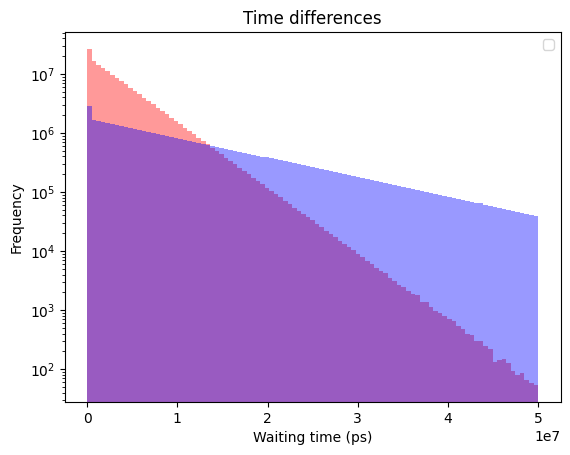

In [88]:
bins = np.linspace(0, np.max(np.concatenate((time_diffsL, time_diffsR))), 100)
bins = np.linspace(0, 50000000, 100)
plt.hist(np.concatenate((time_diffsL, time_diffsR)), bins = bins, color = 'red', alpha = 0.4, label = f'')
plt.hist(np.concatenate((time_diffsL_pcut, time_diffsR_pcut)), bins = bins, color = 'blue', alpha = 0.4, label = f'')
plt.xlabel('Waiting time (ps)')
plt.ylabel('Frequency')
plt.title('Time differences')
plt.yscale('log')
plt.legend()

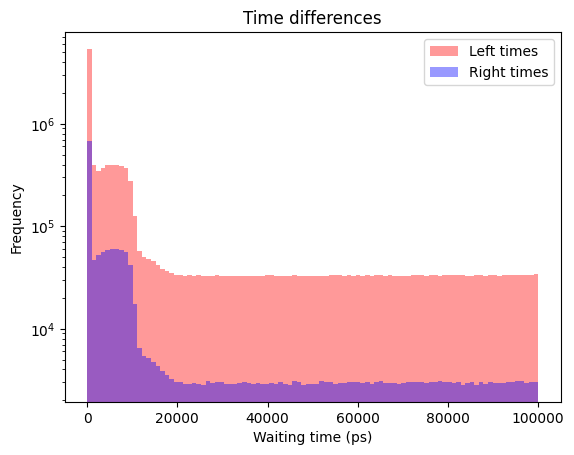

In [89]:
bins = np.linspace(0, 100000, 100)
plt.hist(np.concatenate((time_diffsL, time_diffsR)), bins = bins, color = 'red', alpha = 0.4, label = f'Left times')
plt.hist(np.concatenate((time_diffsL_pcut, time_diffsR_pcut)), bins = bins, color = 'blue', alpha = 0.4, label = f'Right times')
plt.xlabel('Waiting time (ps)')
plt.ylabel('Frequency')
plt.title('Time differences')
plt.yscale('log')
plt.legend()